<a href="https://colab.research.google.com/github/vneumannufprbr/TrabajosenPython/blob/main/Cuaderno_de_An%C3%A1lisis_Validaci%C3%B3n_Predicci%C3%B3n_con_XGBoost_ACF_Decomp_Rolling_Ok_v1_0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Librerías importadas correctamente.
Datos cargados exitosamente con 14 tipos de incidentes.

¿Qué desea hacer? Ingrese 'analizar', 'validar' o 'predecir': predecir

INICIANDO MODO PRODUCCIÓN (ENTRENAMIENTO Y PREDICCIÓN)

--- Entrenando modelo de producción para 'Abigeato' (Ventana de 1 días) ---
Modelo de producción guardado en: modelos_guardados/modelo_abigeato.joblib

--- Entrenando modelo de producción para 'Coaccion sexual' (Ventana de 2 días) ---
Modelo de producción guardado en: modelos_guardados/modelo_coaccion_sexual.joblib

--- Entrenando modelo de producción para 'Homicidio culposo en accidente de transito' (Ventana de 3 días) ---
Modelo de producción guardado en: modelos_guardados/modelo_homicidio_culposo_en_accidente_de_transito.joblib

--- Entrenando modelo de producción para 'Homicidio doloso' (Ventana de 4 días) ---
Modelo de producción guardado en: modelos_guardados/modelo_homicidio_doloso.joblib

--- Entrenando modelo de producción para 'Hurto' (Ventana de 5 días) ---


,Abigeato,Coaccion sexual,Homicidio culposo en accidente de transito,Homicidio doloso,Hurto,Hurto agravado,Lesion,Lesion culposa en accidente de transito,Robo agravado de motocicletas,Robo agravado de objetos,Robo de motocicletas,Robo de objetos,Robo de vehiculos
2025-01-01,1,1,1,1,1,1,2,0,1,2,1,0,1
2025-01-02,1,1,2,1,0,1,2,1,1,2,1,0,1
2025-01-03,1,1,2,1,0,1,2,1,1,2,1,1,1
2025-01-04,1,1,1,1,0,0,2,1,1,2,3,0,1
2025-01-05,1,1,1,1,0,1,2,0,1,2,3,0,1
2025-01-06,1,1,1,1,1,0,2,1,0,1,1,1,1
2025-01-07,1,1,1,1,1,0,2,0,0,1,1,1,1
2025-01-08,1,1,1,1,0,0,2,0,0,2,1,0,0
2025-01-09,1,1,1,1,0,0,2,1,0,2,1,0,0
2025-01-10,1,1,1,1,0,0,2,1,0,2,0,0,1



¡Éxito! El pronóstico ha sido guardado en: 'pronostico_futuro.csv'

GENERANDO GRÁFICOS DE PRONÓSTICO FUTURO


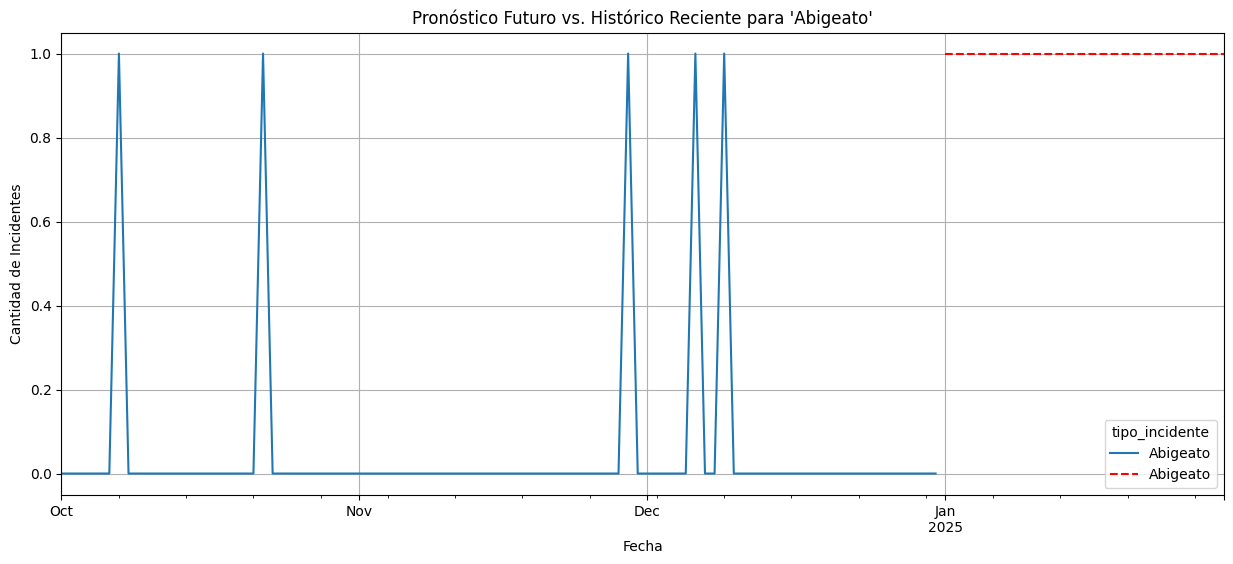

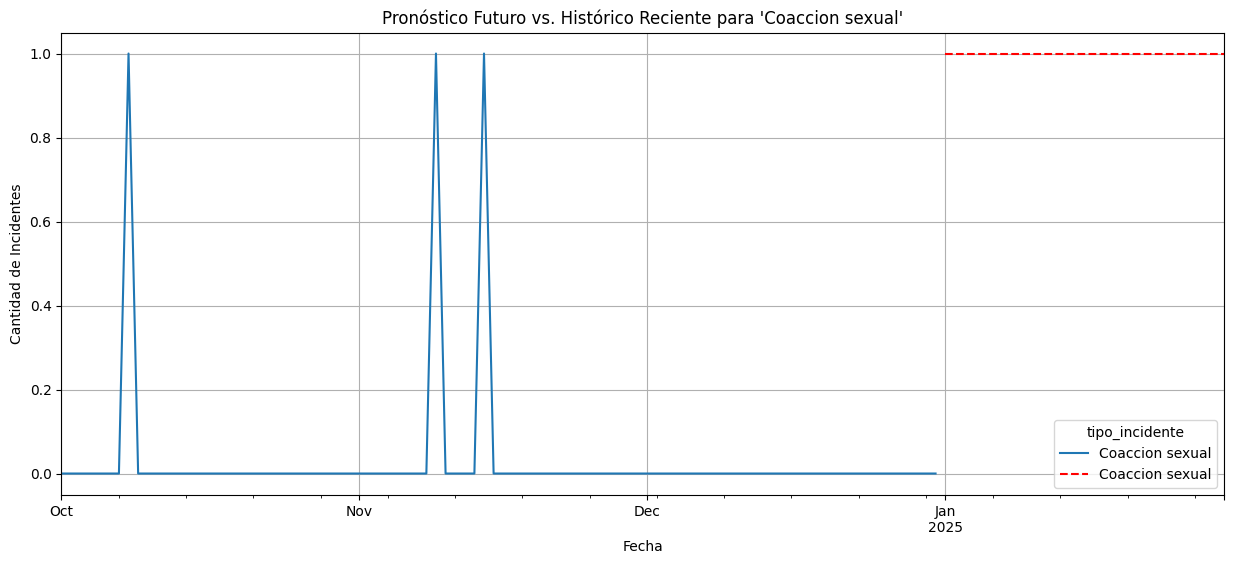

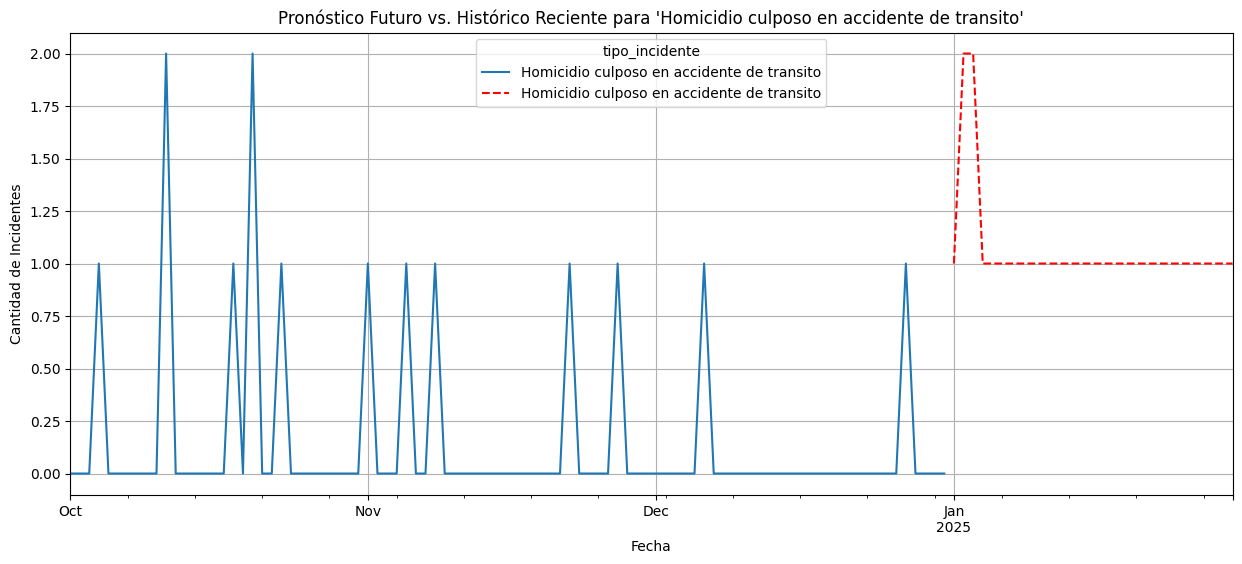

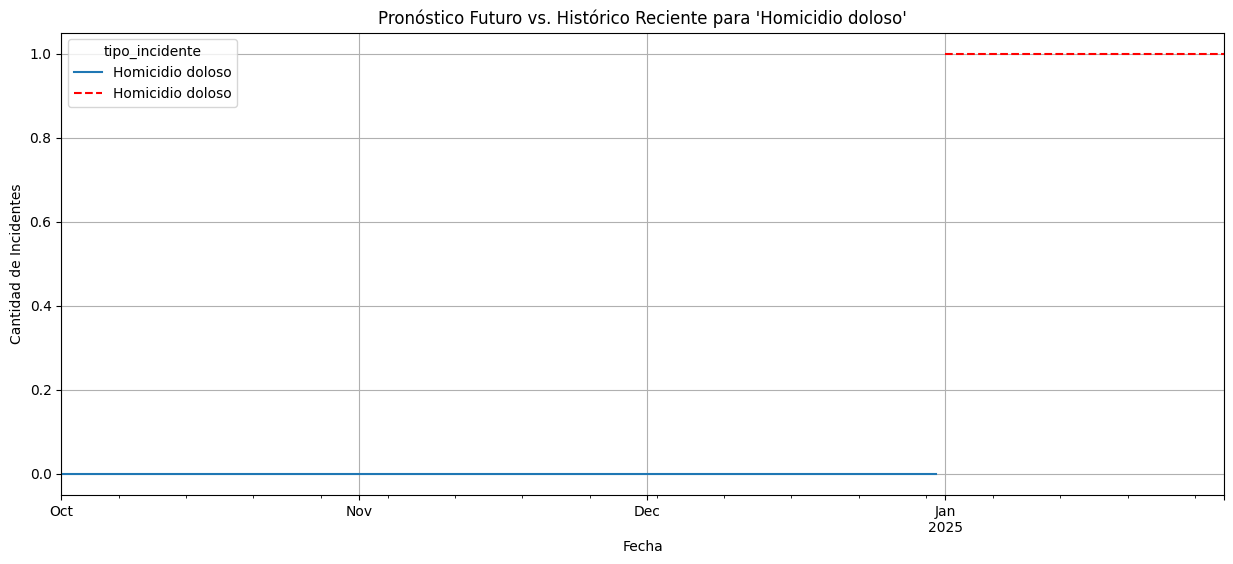

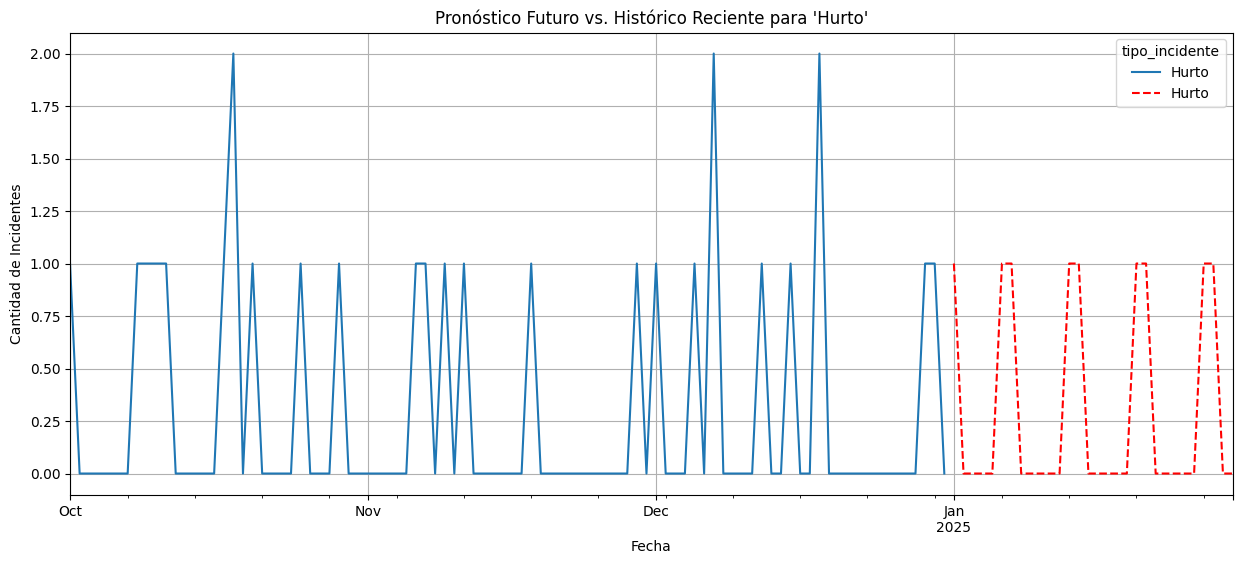

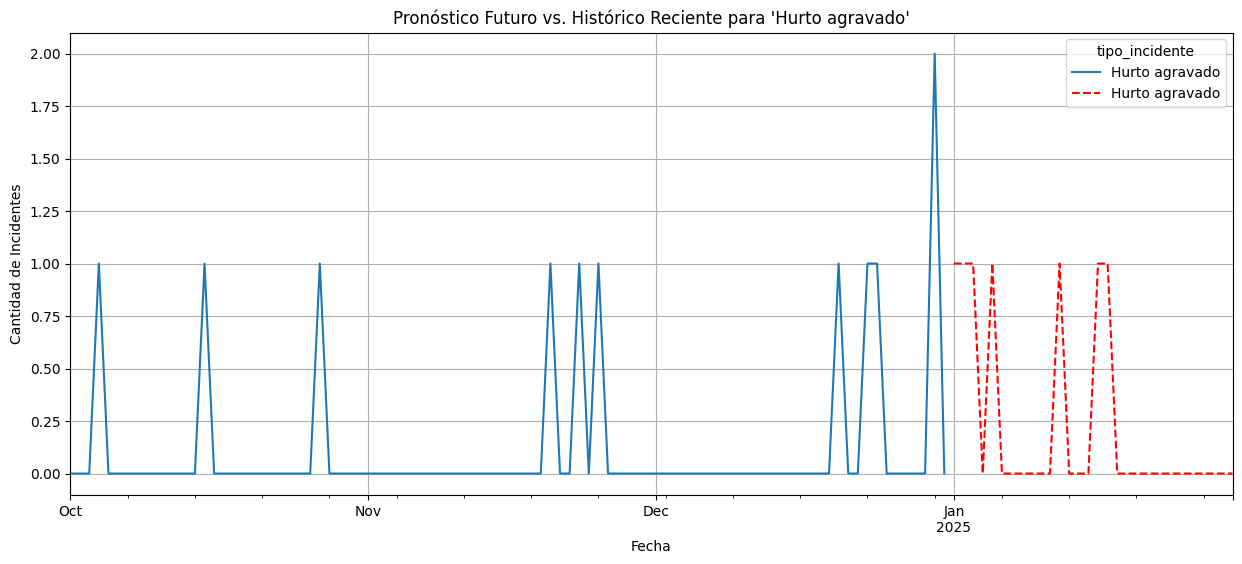

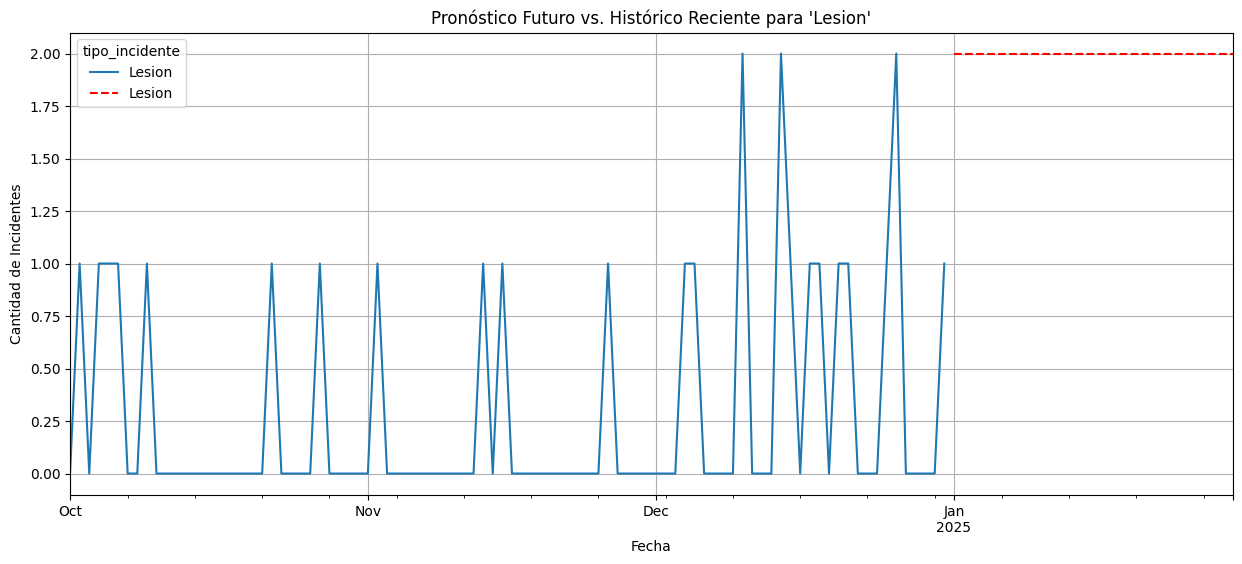

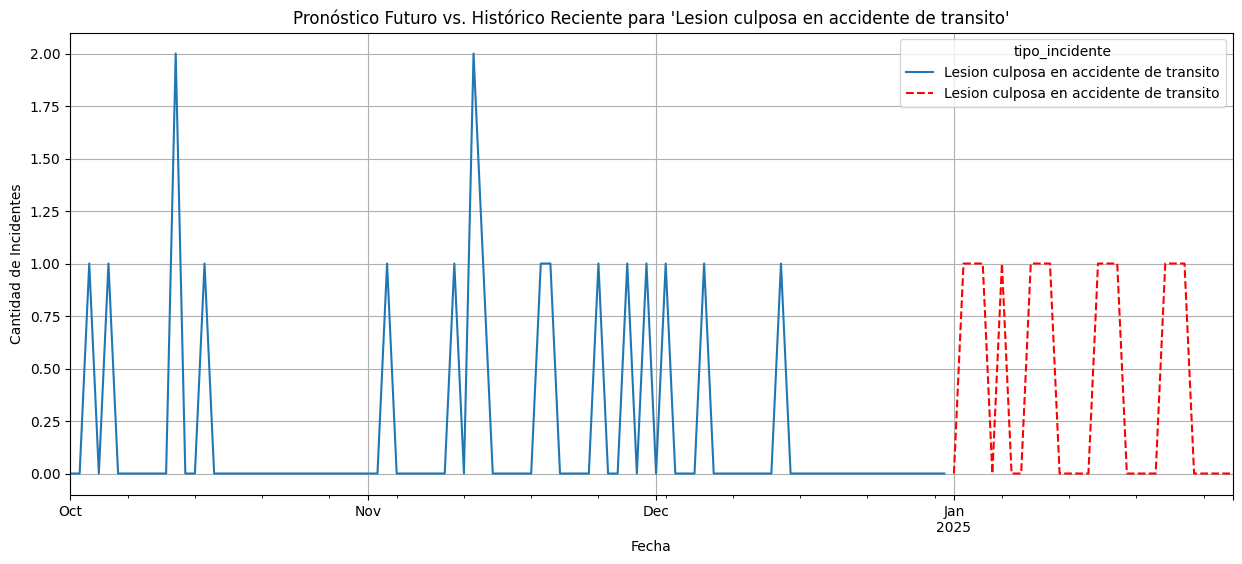

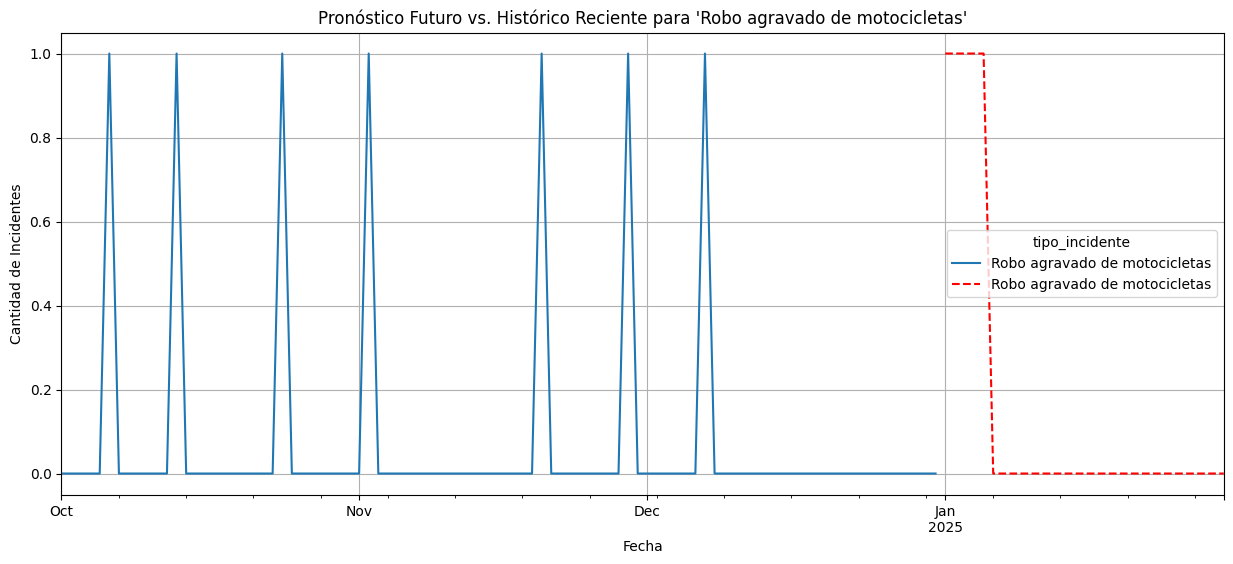

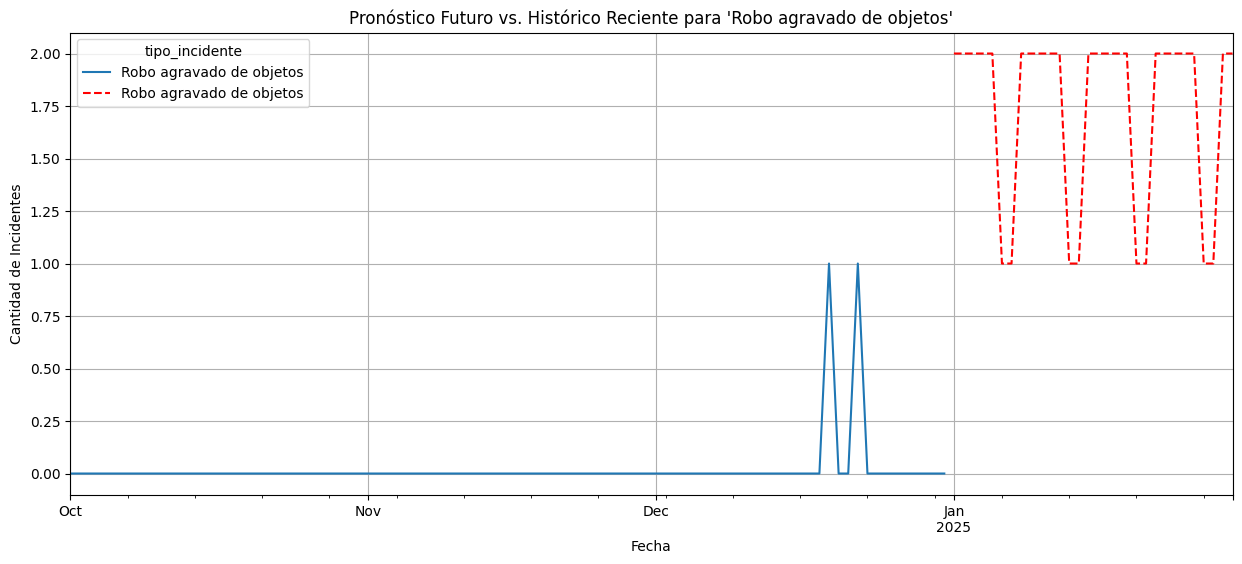

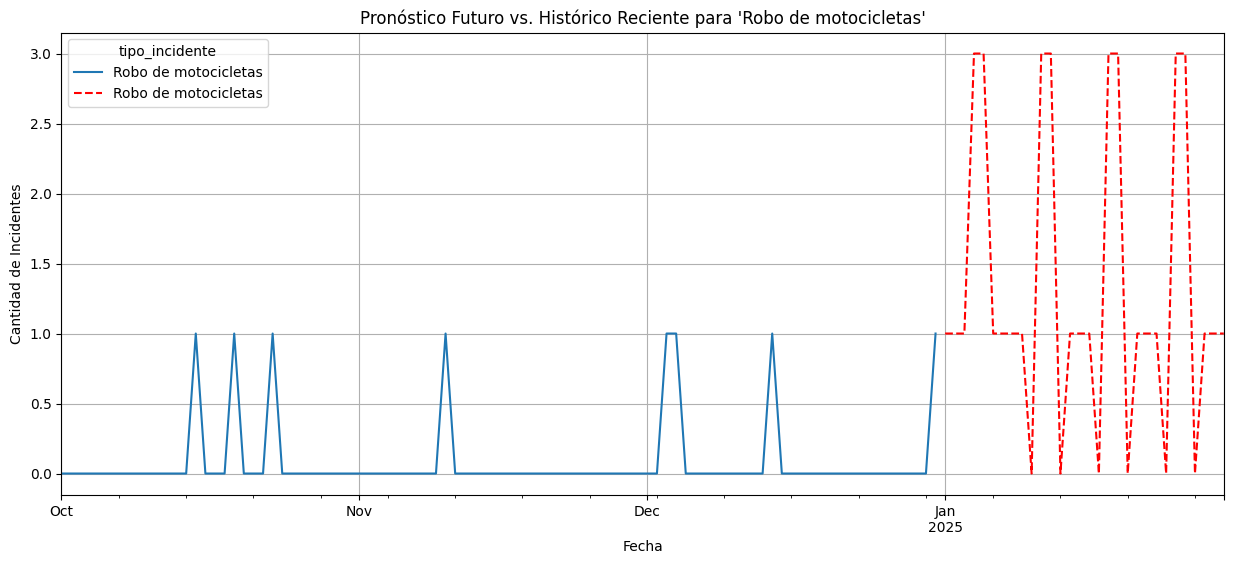

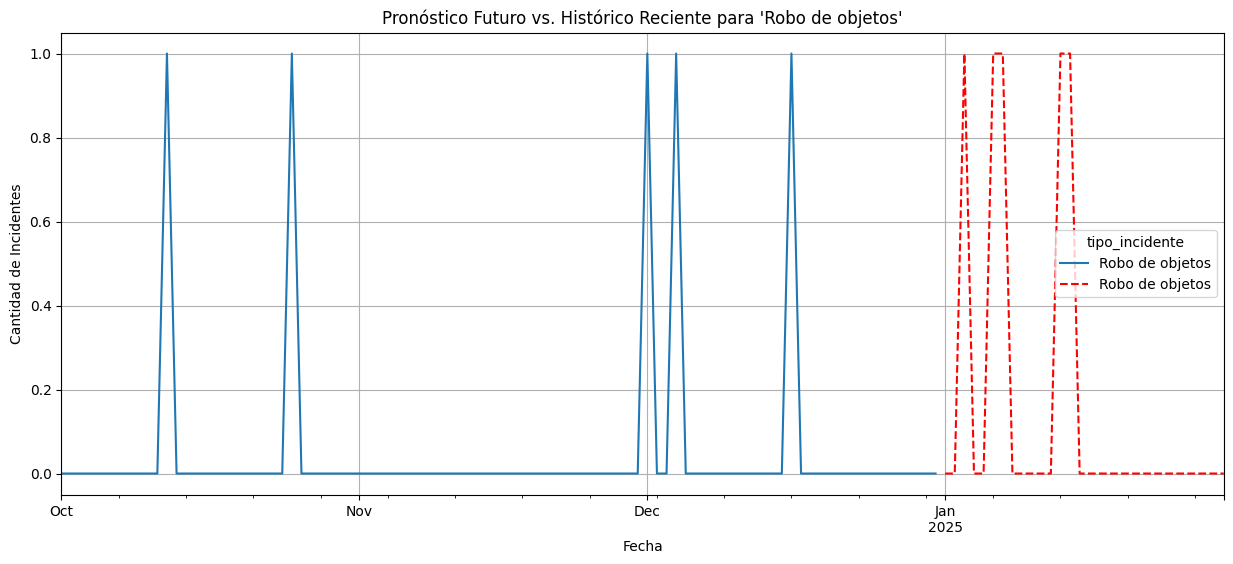

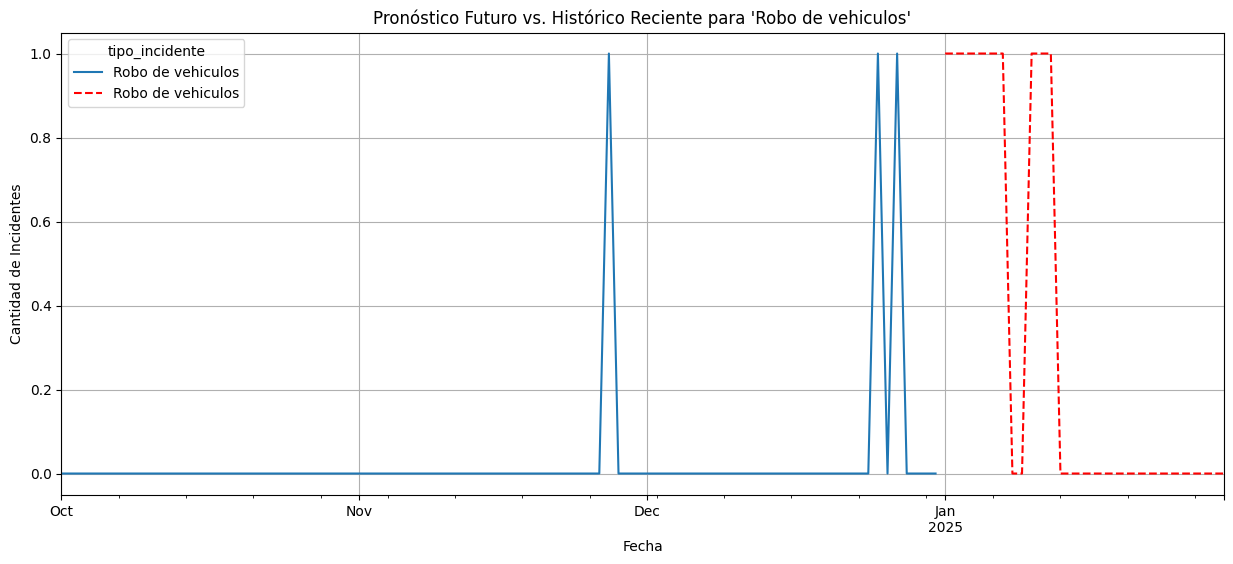

In [5]:
# -*- coding: utf-8 -*-
"""
Cuaderno de Análisis y Predicción Completo (XGBoost)
Versión 1.0 - Con los 3 Modos (analizar, validar, predecir) Funcionales

Objetivo: Ofrecer un flujo de trabajo completo que permita el análisis de
          series temporales (ACF/PACF), la validación de modelos (backtesting)
          y la generación de pronósticos de producción.
"""

# -----------------------------------------------------------------------------
# Paso 1: Importación de Librerías
# -----------------------------------------------------------------------------
import pandas as pd
import numpy as np
import xgboost as xgb
import holidays
import joblib
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, r2_score
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose # Importar seasonal_decompose
import warnings

warnings.filterwarnings('ignore', category=FutureWarning)
print("Librerías importadas correctamente.")

# -----------------------------------------------------------------------------
# --- CONFIGURACIÓN DE PARÁMETROS ---
# -----------------------------------------------------------------------------
# Se eliminó el tamaño global de la ventana móvil (ROLLING_WINDOW_SIZE)
LAGS_TO_PLOT = 40

# Definir un diccionario para los tamaños de la ventana móvil por tipo de incidente
ROLLING_WINDOW_SIZES = {
    'Abigeato': 1,
    'Coaccion sexual': 2,
    'Homicidio culposo en accidente de transito': 3,
    'Homicidio doloso': 4,
    'Hurto': 5,
    'Hurto agravado': 6,
    'Lesion': 7,
    'Lesion culposa en accidente de transito': 8,
    'Robo agravado de motocicletas': 9,
    'Robo agravado de objetos': 10,
    'Robo agravado de vehiculos': 11, # Este tenía datos insuficientes, pero se incluye para completitud
    'Robo de motocicletas': 12,
    'Robo de objetos': 13,
    'Robo de vehiculos': 14,
}


# -----------------------------------------------------------------------------
# Paso 2: Funciones Comunes
# -----------------------------------------------------------------------------

def crear_caracteristicas(dataframe, target_column=None, window_size=7):
    """Crea características de series temporales."""
    df_copy = dataframe.copy()
    df_copy['dia_de_la_semana'] = df_copy.index.dayofweek
    df_copy['mes'] = df_copy.index.month
    df_copy['anio'] = df_copy.index.year
    df_copy['dia_del_anio'] = df_copy.index.dayofyear
    df_copy['semana_del_anio'] = df_copy.index.isocalendar().week.astype(int)
    py_holidays = holidays.Paraguay(years=df_copy.index.year.unique())
    df_copy['es_feriado'] = df_copy.index.isin(py_holidays).astype(int)
    if target_column:
        df_copy['lag1'] = df_copy[target_column].shift(1)
        df_copy['lag7'] = df_copy[target_column].shift(7)
        # Usar un nombre genérico para la característica de promedio móvil
        df_copy['rolling_mean'] = df_copy[target_column].rolling(window=window_size).mean()
    return df_copy

# -----------------------------------------------------------------------------
# --- MODO ANÁLISIS ---
# -----------------------------------------------------------------------------

def analizar_series_temporales(dataframe, lags):
    """Genera gráficos ACF, PACF y descomposición estacional para cada tipo de incidente."""
    print("\n" + "="*70)
    print("INICIANDO MODO ANÁLISIS (ACF/PACF y Descomposición Estacional)") # Actualizar mensaje
    print("="*70)
    for incidente in dataframe.columns:
        print(f"\n--- Análisis para: '{incidente}' ---")
        if dataframe[incidente].sum() < 20:
            print("Datos insuficientes para un análisis de autocorrelación significativo.")
            continue

        # Gráficos ACF y PACF
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 8))
        plot_acf(dataframe[incidente], ax=ax1, lags=lags)
        ax1.set_title(f'Función de Autocorrelación (ACF) para {incidente}')
        ax1.grid(True)
        plot_pacf(dataframe[incidente], ax=ax2, lags=lags)
        ax2.set_title(f'Función de Autocorrelación Parcial (PACF) para {incidente}')
        ax2.grid(True)
        plt.tight_layout()
        plt.show()

        # Descomposición Estacional
        print(f"--- Descomposición Estacional para: '{incidente}' ---")
        try:
            # Intentar descomposición aditiva
            result = seasonal_decompose(dataframe[incidente], model='additive', period=365) # Asumir estacionalidad anual (365 días)
            fig = result.plot()
            fig.set_size_inches(15, 10)
            fig.suptitle(f'Descomposición Estacional Aditiva para {incidente}', y=1.02)

            # Traducir títulos de ejes Y y aumentar tamaño eje X
            axes = fig.get_axes()
            axes[0].set_ylabel('Observado')
            axes[1].set_ylabel('Tendencia')
            axes[2].set_ylabel('Estacionalidad')
            axes[3].set_ylabel('Residuo')

            # Aumentar tamaño del eje X (se aplica a todos los subplots)
            for ax in axes:
                 ax.tick_params(axis='x', labelsize=10) # Ajusta el tamaño según sea necesario

            plt.tight_layout()
            plt.show()
        except Exception as e:
            print(f"No se pudo realizar la descomposición estacional aditiva para '{incidente}': {e}")
            try:
                # Si falla la aditiva, intentar la multiplicativa (si los valores son > 0)
                if (dataframe[incidente] > 0).all():
                    result = seasonal_decompose(dataframe[incidente], model='multiplicative', period=365)
                    fig = result.plot()
                    fig.set_size_inches(15, 10)
                    fig.suptitle(f'Descomposición Estacional Multiplicativa para {incidente}', y=1.02)

                    # Traducir títulos de ejes Y y aumentar tamaño eje X para descomposición multiplicativa
                    axes = fig.get_axes()
                    axes[0].set_ylabel('Observado')
                    axes[1].set_ylabel('Tendencia')
                    axes[2].set_ylabel('Estacionalidad')
                    axes[3].set_ylabel('Residuo')

                    for ax in axes:
                         ax.tick_params(axis='x', labelsize=10) # Ajusta el tamaño según sea necesario

                    plt.tight_layout()
                    plt.show()
                else:
                    print("No se puede realizar descomposición multiplicativa con valores cero o negativos.")
            except Exception as e:
                print(f"No se pudo realizar la descomposición estacional multiplicativa para '{incidente}': {e}")


# -----------------------------------------------------------------------------
# --- MODO VALIDACIÓN ---
# -----------------------------------------------------------------------------

def validar_modelo(dataframe, target_column, rolling_window_sizes):
    """Entrena, evalúa y muestra la importancia de las variables de un modelo."""
    # Recuperar el tamaño específico de la ventana para la columna target actual
    window_size = rolling_window_sizes.get(target_column, 7) # Por defecto 7 si no se encuentra
    print("-" * 70)
    # Actualizar la instrucción de impresión para mostrar el tamaño específico de la ventana utilizada
    print(f"VALIDANDO MODELO PARA: '{target_column}' (Ventana de {window_size} días)")

    # Pasar el tamaño específico de la ventana a crear_caracteristicas
    df_model = crear_caracteristicas(dataframe[[target_column]], target_column, window_size).dropna()
    fecha_corte = df_model.index.max() - pd.DateOffset(months=3)
    train_df, test_df = df_model.loc[df_model.index <= fecha_corte], df_model.loc[df_model.index > fecha_corte]

    if test_df.empty or train_df.empty or train_df[target_column].sum() < 10:
        print(f"Datos insuficientes para validar.")
        return None

    features = [col for col in train_df.columns if col != target_column]
    X_train, y_train, X_test, y_test = train_df[features], train_df[target_column], test_df[features], test_df[target_column]

    reg = xgb.XGBRegressor(n_estimators=1000, learning_rate=0.01, max_depth=5, early_stopping_rounds=20, objective='reg:squarederror', random_state=42) # Modelado con XGBoost
    reg.fit(X_train, y_train, eval_set=[(X_train, y_train), (X_test, y_test)], verbose=False)

    y_pred = reg.predict(X_test)
    rmse, r2 = np.sqrt(mean_squared_error(y_test, y_pred)), r2_score(y_test, y_pred)

    print(f"\nRESULTADOS DE VALIDACIÓN:\n  - RMSE: {rmse:.2f} | R² (Precisión): {r2:.2f}")

    feature_importance = pd.DataFrame(data=reg.feature_importances_, index=reg.feature_names_in_, columns=['Importancia']).sort_values('Importancia', ascending=False)

    # Aplicar traducciones para imprimir, manejando posibles traducciones faltantes
    # Usar una clave genérica para el promedio móvil en las traducciones
    traducciones = {'dia_de_la_semana': 'Día de la Semana', 'mes': 'Mes del Año', 'anio': 'Año', 'dia_del_anio': 'Día del Año', 'semana_del_anio': 'Semana del Año', 'es_feriado': 'Es Feriado', 'lag1': 'Delitos (Día Anterior)', 'lag7': 'Delitos (Semana Anterior)', 'rolling_mean': f'Promedio Móvil ({window_size} Días)'}
    translated_index = feature_importance.index.map(traducciones)
    # Usar fillna en una Serie con el índice original como una Serie
    feature_importance_translated = feature_importance.copy()
    feature_importance_translated.index = pd.Series(translated_index).fillna(pd.Series(feature_importance.index))


    print("\nIMPORTANCIA DE VARIABLES PARA ESTE MODELO:")
    print(feature_importance_translated.head(5))
    print("-" * 70)

    test_df['prediccion'] = y_pred
    fig, ax = plt.subplots(figsize=(15, 6))
    train_df.loc[train_df.index > fecha_corte - pd.DateOffset(months=9)][target_column].plot(ax=ax, label='Datos de Entrenamiento', legend=True)
    test_df[target_column].plot(ax=ax, label=f'Datos Reales ({target_column})', legend=True)
    test_df['prediccion'].plot(ax=ax, label=f'Predicciones ({target_column})', legend=True, color='red', linestyle='--')
    ax.set_title(f"Validación de Pronóstico para '{target_column}' (Ventana: {window_size})")
    ax.set_xlabel('Fecha')
    ax.set_ylabel('Cantidad de Incidentes')
    ax.grid(True)
    plt.show()

    return feature_importance_translated

# -----------------------------------------------------------------------------
# --- MODO PRODUCCIÓN ---
# -----------------------------------------------------------------------------

def entrenar_y_guardar_modelo(dataframe, target_column, model_path, rolling_window_sizes):
    """Entrena un modelo con TODOS los datos disponibles y lo guarda."""
    # Recuperar el tamaño específico de la ventana para la columna target actual
    window_size = rolling_window_sizes.get(target_column, 7) # Por defecto 7 si no se encuentra
    print(f"\n--- Entrenando modelo de producción para '{target_column}' (Ventana de {window_size} días) ---") # Actualizar instrucción de impresión

    # Pasar el tamaño específico de la ventana a crear_caracteristicas
    df_model_full = crear_caracteristicas(dataframe[[target_column]], target_column, window_size).dropna()
    if df_model_full.empty or df_model_full[target_column].sum() < 20:
        print(f"Datos insuficientes. No se guardará el modelo.")
        return
    features = [col for col in df_model_full.columns if col != target_column]
    X_train_full, y_train_full = df_model_full[features], df_model_full[target_column]
    reg = xgb.XGBRegressor(n_estimators=500, learning_rate=0.01, max_depth=5, objective='reg:squarederror', random_state=42) # Modelado con XGBoost con datos completos
    reg.fit(X_train_full, y_train_full, verbose=False)
    joblib.dump(reg, model_path)
    print(f"Modelo de producción guardado en: {model_path}")

def cargar_y_predecir(model_path, historical_df, future_dates, rolling_window_sizes):
    """Carga un modelo guardado y predice sobre fechas futuras."""
    try:
        model = joblib.load(model_path)
    except FileNotFoundError:
        print(f"Error: Modelo no encontrado en {model_path}")
        return None

    # Obtener el nombre de la columna de incidentes target del historical_df
    target_column = historical_df.columns[0]

    # Recuperar el tamaño específico de la ventana para la columna target actual
    window_size = rolling_window_sizes.get(target_column, 7) # Por defecto 7 si no se encuentra

    print(f"--- Generando predicciones para '{target_column}' (Ventana de {window_size} días) ---") # Agregar instrucción de impresión

    df_future_with_history = pd.concat([historical_df, pd.DataFrame(index=future_dates)])
    # Pasar el tamaño específico de la ventana a crear_caracteristicas
    df_features_full = crear_caracteristicas(df_future_with_history, target_column, window_size)

    # Asegurarse de que las características coincidan con aquellas con las que se entrenó el modelo
    # Crear una lista de nombres de características esperadas basada en los nombres de características del modelo
    expected_feature_names = model.get_booster().feature_names

    # Excluir la columna target de las características utilizadas para la predicción
    features_for_prediction = [col for col in df_features_full.columns if col != target_column]


    # Verificar si las características generadas coinciden con las características esperadas
    # Comparar la lista de características para la predicción con los nombres de características esperados
    if set(expected_feature_names) != set(features_for_prediction):
         print(f"Error: Las características del modelo no coinciden con las características generadas para la predicción para '{target_column}'.")
         print(f"Características esperadas: {sorted(expected_feature_names)}")
         print(f"Características generadas: {sorted(features_for_prediction)}") # Imprimir las características generadas corregidas
         return None


    X_future = df_features_full.loc[future_dates]
    # Asegurarse de que el orden de las columnas en X_future coincida con el orden en model.get_booster().feature_names
    # Seleccionar solo las características para la predicción
    X_future_final = X_future[expected_feature_names]
    predictions = model.predict(X_future_final)
    return np.round(np.maximum(0, predictions)).astype(int)

# =============================================================================
# --- PUNTO DE ENTRADA PRINCIPAL ---
# =============================================================================

if __name__ == '__main__':
    try:
        df_incidents = pd.read_csv('incidentes_ampliados_7_anios_completo.csv', encoding='utf-8')
        df_incidents['fecha'] = pd.to_datetime(df_incidents['fecha'])
        df_pivot = pd.pivot_table(df_incidents, index='fecha', columns='tipo_incidente', aggfunc='size', fill_value=0)
        date_rng = pd.date_range(start=df_pivot.index.min(), end=df_pivot.index.max(), freq='D')
        df_granular = df_pivot.reindex(date_rng, fill_value=0)
        print(f"Datos cargados exitosamente con {len(df_granular.columns)} tipos de incidentes.")
    except FileNotFoundError:
        print("\nERROR: El archivo 'incidentes_ampliados_7_anios_completo.csv' no se encontró.")
        exit()

    while True:
        modo = input("\n¿Qué desea hacer? Ingrese 'analizar', 'validar' o 'predecir': ").lower().strip()
        if modo in ['analizar', 'validar', 'predecir']:
            break
        else:
            print("Entrada no válida. Por favor, intente de nuevo.")

    if modo == 'analizar':
        analizar_series_temporales(df_granular, lags=LAGS_TO_PLOT)

    elif modo == 'validar':
        print("\n" + "="*70)
        print("INICIANDO MODO VALIDACIÓN (BACKTESTING)")
        print("="*70)
        importancia_total = []
        for incidente in df_granular.columns:
            # Pasar ROLLING_WINDOW_SIZES a validar_modelo
            importancia = validar_modelo(df_granular, incidente, rolling_window_sizes=ROLLING_WINDOW_SIZES)
            if importancia is not None:
                importancia['tipo_incidente'] = incidente
                importancia_total.append(importancia)
        if importancia_total:
            df_importancia_total = pd.concat(importancia_total).reset_index().rename(columns={'index': 'feature'})
            # Aplicar el mapeo de traducción a la columna 'feature'
            # Necesidad de generar dinámicamente la clave de traducción del promedio móvil basada en el tamaño de la ventana utilizada para cada incidente
            # Como estamos promediando la importancia en diferentes tamaños de ventana, usar una clave genérica para graficar
            traducciones_plot = {'dia_de_la_semana': 'Día de la Semana', 'mes': 'Mes del Año', 'anio': 'Año', 'dia_del_anio': 'Día del Año', 'semana_del_anio': 'Semana del Año', 'es_feriado': 'Es Feriado', 'lag1': 'Delitos (Día Anterior)', 'lag7': 'Delitos (Semana Anterior)', 'rolling_mean': 'Promedio Móvil (Varios Días)'}

            # Reemplazar las claves específicas de promedio móvil con una genérica para agregación y graficación
            def translate_feature_for_plot(feature, traducciones_plot):
                # Usar la clave genérica 'rolling_mean' para la traducción
                if feature == 'rolling_mean':
                    return traducciones_plot.get(feature, feature)
                return traducciones_plot.get(feature, feature)


            df_importancia_total['feature_translated'] = df_importancia_total['feature'].apply(lambda x: translate_feature_for_plot(x, traducciones_plot))


            plt.figure(figsize=(12, 8))
            # Graficar usando la columna de características traducidas para la agregación
            sns.barplot(x='Importancia', y='feature_translated', data=df_importancia_total.groupby('feature_translated')['Importancia'].mean().sort_values(ascending=False).reset_index(), palette='viridis')
            plt.title('Importancia Promedio de las Variables (Todos los Modelos)')
            plt.xlabel('Nivel de Importancia Promedio')
            plt.ylabel('Variable Predictora')
            plt.tight_layout()
            plt.show()

    elif modo == 'predecir':
        print("\n" + "="*70)
        print("INICIANDO MODO PRODUCCIÓN (ENTRENAMIENTO Y PREDICCIÓN)")
        print("="*70)
        model_dir = "modelos_guardados"
        if not os.path.exists(model_dir):
            os.makedirs(model_dir)

        for incidente in df_granular.columns:
            model_path = os.path.join(model_dir, f"modelo_{incidente.lower().replace(' ', '_')}.joblib")
            # Pasar ROLLING_WINDOW_SIZES a entrenar_y_guardar_modelo
            entrenar_y_guardar_modelo(df_granular, incidente, model_path, rolling_window_sizes=ROLLING_WINDOW_SIZES)

        while True:
            try:
                dias_str = input("\n¿Cuántos días hacia el futuro desea predecir? (1-90): ")
                dias_a_predecir = int(dias_str)
                if 1 <= dias_a_predecir <= 90: break
                else: print("Error: Por favor, ingrese un número entre 1 y 90.")
            except ValueError:
                print("Error: Entrada no válida. Ingrese un número entero.")

        last_known_date = df_granular.index.max()
        future_dates = pd.date_range(start=last_known_date + pd.Timedelta(days=1), periods=dias_a_predecir, freq='D')
        df_pronostico_total = pd.DataFrame(index=future_dates)

        print(f"\nGenerando pronóstico para los próximos {dias_a_predecir} días...")

        for incidente in df_granular.columns:
            model_path = os.path.join(model_dir, f"modelo_{incidente.lower().replace(' ', '_')}.joblib")
            # Pasar ROLLING_WINDOW_SIZES a cargar_y_predecir
            predicciones = cargar_y_predecir(model_path, df_granular[[incidente]], future_dates, rolling_window_sizes=ROLLING_WINDOW_SIZES)
            if predicciones is not None:
                df_pronostico_total[incidente] = predicciones

        df_pronostico_final = df_pronostico_total.fillna(0).astype(int)

        print("\n" + "-"*70)
        print(f"RESULTADO FINAL: TABLA DE PRONÓSTICO")
        print("-" * 70)
            # Mostrar el DataFrame completo sin truncamiento
        display(df_pronostico_final)


        output_filename = 'pronostico_futuro.csv'
        df_pronostico_final.to_csv(output_filename, encoding='utf-8')
        print(f"\n¡Éxito! El pronóstico ha sido guardado en: '{output_filename}'")

        print("\n" + "="*70)
        print("GENERANDO GRÁFICOS DE PRONÓSTICO FUTURO")
        print("="*70)
        for incidente in df_pronostico_final.columns:
            if incidente in df_granular.columns:
                fig, ax = plt.subplots(figsize=(15, 6))
                historial_reciente = df_granular.loc[df_granular.index > last_known_date - pd.DateOffset(months=3)][[incidente]]
                historial_reciente.plot(ax=ax, label=f'Histórico Real ({incidente})', legend=True)
                df_pronostico_final[[incidente]].plot(ax=ax, label=f'Pronóstico Futuro ({incidente})', legend=True, color='red', linestyle='--')
                ax.set_title(f"Pronóstico Futuro vs. Histórico Reciente para '{incidente}'")
                ax.set_xlabel('Fecha')
                ax.set_ylabel('Cantidad de Incidentes')
                ax.grid(True)
                plt.show()